<a href="https://colab.research.google.com/github/sandinaniaaryan-afk/ML/blob/main/lab05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded shape: (249, 9)
           Date Month  Day    Price     Open     High      Low   Volume  \
0  Jun 29, 2021   Jun  Tue  2081.85  2092.00  2126.90  2065.05    1.67M   
1  Jun 28, 2021   Jun  Mon  2077.75  2084.00  2112.45  2068.40  707.73K   
2  Jun 25, 2021   Jun  Fri  2068.85  2084.35  2088.50  2053.10  475.82K   
3  Jun 24, 2021   Jun  Thu  2072.95  2098.00  2098.00  2066.00  541.51K   
4  Jun 23, 2021   Jun  Wed  2078.25  2102.00  2111.40  2072.00  809.62K   

     Chg%  
0  0.0020  
1  0.0043  
2 -0.0020  
3 -0.0026  
4 -0.0023  

X: (249, 7), y: (249,)
Target mean=1560.66, std=241.86, min=1300.55, max=2144.85
Train: 199, Test: 50
k=1: scratch=0.9833, sklearn=0.9833, weighted=0.9833
k=2: scratch=0.9840, sklearn=0.9840, weighted=0.9845
k=3: scratch=0.9850, sklearn=0.9850, weighted=0.9853
k=4: scratch=0.9847, sklearn=0.9847, weighted=0.9852
k=5: scratch=0.9844, sklearn=0.9844, weighted=0.9851
k=6: scratch=0.9854, sklearn=0.9854, weighted=0.9860
k=7: scratch=0.9852, sklearn=0.98

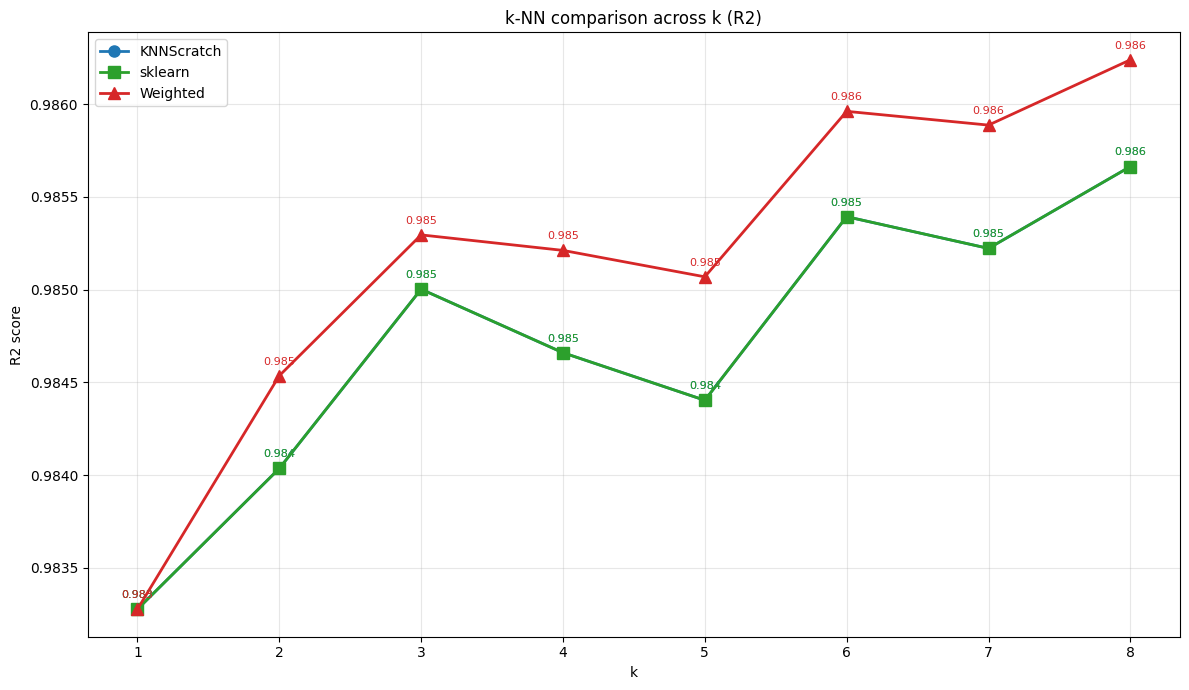

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score


def lp_distance(vector_a, vector_b, order=2):
    diff = np.abs(vector_a - vector_b)
    if np.isinf(order):
        return np.max(diff)
    return np.power(np.sum(np.power(diff, order)), 1.0 / order)


def lp_distance_batch(reference_points, query_point, order=2):
    diff = np.abs(reference_points - query_point)
    if np.isinf(order):
        return np.max(diff, axis=1)
    return np.power(np.sum(np.power(diff, order), axis=1), 1.0 / order)


def _selection_sort_indices(distances, k):
    idx = list(range(len(distances)))
    limit = min(k, len(idx))
    for i in range(limit):
        min_pos = i
        for j in range(i + 1, len(idx)):
            if distances[idx[j]] < distances[idx[min_pos]]:
                min_pos = j
        idx[i], idx[min_pos] = idx[min_pos], idx[i]
    return idx[:limit]


def _merge_sort_indices(distances, k):
    idx = list(range(len(distances)))

    def merge(left, right):
        merged, i, j = [], 0, 0
        while i < len(left) and j < len(right):
            if distances[left[i]] <= distances[right[j]]:
                merged.append(left[i])
                i += 1
            else:
                merged.append(right[j])
                j += 1
        merged.extend(left[i:])
        merged.extend(right[j:])
        return merged

    def sort(items):
        if len(items) <= 1:
            return items
        mid = len(items) // 2
        return merge(sort(items[:mid]), sort(items[mid:]))

    return sort(idx)[:k]


def _quicksort_indices(distances, k):
    idx = list(range(len(distances)))

    def sort(items):
        if len(items) <= 1:
            return items
        pivot = distances[items[len(items) // 2]]
        smaller = [i for i in items if distances[i] < pivot]
        equal = [i for i in items if distances[i] == pivot]
        larger = [i for i in items if distances[i] > pivot]
        return sort(smaller) + equal + sort(larger)

    return sort(idx)[:k]


def _partition_indices(distances, k):
    k = min(k, len(distances))
    unordered = np.argpartition(distances, k - 1)[:k]
    return unordered[np.argsort(distances[unordered])].tolist()


NEIGHBOR_STRATEGIES = {
    "selection": _selection_sort_indices,
    "merge": _merge_sort_indices,
    "quick": _quicksort_indices,
    "partition": _partition_indices,
}


def vote_majority(labels, distances):
    counts = Counter(labels)
    top_count = max(counts.values())
    tied = {label for label, c in counts.items() if c == top_count}
    for _, label in sorted(zip(distances, labels), key=lambda pair: pair[0]):
        if label in tied:
            return label
    return labels[0]


def vote_distance_weighted(labels, distances):
    weights = defaultdict(float)
    for dist, label in zip(distances, labels):
        weights[label] += 1.0 / (dist + 1e-10)
    return max(weights.items(), key=lambda pair: pair[1])[0]


class KNNScratch:

    def __init__(self, k=3, order=2, strategy="partition", weighted=False, task="regression"):
        if strategy not in NEIGHBOR_STRATEGIES:
            raise ValueError(f"Unknown strategy '{strategy}', choose from {list(NEIGHBOR_STRATEGIES)}")
        if task not in ("regression", "classification"):
            raise ValueError("task must be 'regression' or 'classification'")

        self.k = k
        self.order = order
        self.strategy = strategy
        self.weighted = weighted
        self.task = task
        self._X = None
        self._y = None

    def fit(self, X, y):
        self._X = np.asarray(X, dtype=float)
        self._y = np.asarray(y)
        self.k = max(1, min(self.k, len(self._X)))
        return self

    def _neighbors_for(self, point):
        distances = lp_distance_batch(self._X, point, self.order)
        pick = NEIGHBOR_STRATEGIES[self.strategy](distances, self.k)
        return distances[pick], self._y[pick]

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        out = []

        for point in X:
            dist, labels = self._neighbors_for(point)

            if self.task == "regression":
                if self.weighted:
                    w = 1.0 / (dist + 1e-10)
                    out.append(np.average(labels, weights=w))
                else:
                    out.append(np.mean(labels))
            else:
                if self.weighted:
                    out.append(vote_distance_weighted(list(labels), list(dist)))
                else:
                    out.append(vote_majority(list(labels), list(dist)))

        return np.array(out)

    def score(self, X, y):
        preds = self.predict(X)
        y = np.asarray(y)
        if self.task == "regression":
            return r2_score(y, preds)
        return np.mean(preds == y)


def drop_empty_columns(df):
    return df.dropna(axis=1, how="all")


def drop_rows_missing_target(target_column):
    def _step(df):
        return df.dropna(subset=[target_column]) if target_column in df.columns else df
    return _step


def drop_junk_columns(df):
    junk_mask = df.columns.str.match(r"^Unnamed")
    named_junk = [c for c in ("Customer", "Date") if c in df.columns]
    return df.drop(columns=list(df.columns[junk_mask]) + named_junk, errors="ignore")


def impute_missing(strategy="median"):
    reducers = {
        "mean": lambda s: s.mean(),
        "median": lambda s: s.median(),
        "mode": lambda s: s.mode().iloc[0],
    }

    if strategy not in reducers:
        raise ValueError("strategy must be mean, median or mode")

    def _step(df):
        df = df.copy()

        for col in df.select_dtypes(include=np.number).columns:
            if df[col].isnull().any():
                df[col] = df[col].fillna(reducers[strategy](df[col].dropna()))

        for col in df.select_dtypes(include=["object", "category"]).columns:
            df[col] = df[col].fillna("MISSING")

        return df

    return _step


def encode_categoricals(skip_column=None):
    def _step(df):
        df = df.copy()

        for col in df.select_dtypes(include=["object", "category"]).columns:
            if col == skip_column:
                continue
            codes, _ = pd.factorize(df[col], sort=True)
            df[col] = codes

        return df

    return _step


def run_pipeline(df, steps):
    for step in steps:
        df = step(df)
    return df


def build_features_and_target(df, target_column):
    if target_column in df.columns:
        y = df[target_column]
        X = df.drop(columns=[target_column])
    else:
        X, y = df.iloc[:, :-1], df.iloc[:, -1]

    X = X.select_dtypes(include=[np.number])
    return X.to_numpy(dtype=float), y.to_numpy()


def preprocess(df, target_column, imputation_strategy="median"):
    pipeline = [
        drop_empty_columns,
        drop_rows_missing_target(target_column),
        drop_junk_columns,
        impute_missing(imputation_strategy),
        encode_categoricals(skip_column=target_column),
    ]

    clean_df = run_pipeline(df, pipeline)
    return build_features_and_target(clean_df, target_column)


def plot_k_comparison(k_values, results, metric_name="R2"):
    fig, ax = plt.subplots(figsize=(12, 7))

    markers = {
        "KNNScratch": "o",
        "sklearn": "s",
        "Weighted": "^"
    }

    colors = {
        "KNNScratch": "tab:blue",
        "sklearn": "tab:green",
        "Weighted": "tab:red"
    }

    for label, scores in results.items():
        ax.plot(
            k_values,
            scores,
            marker=markers.get(label, "o"),
            linewidth=2,
            markersize=8,
            label=label,
            color=colors.get(label),
        )

        for k, score in zip(k_values, scores):
            ax.annotate(
                f"{score:.3f}",
                (k, score),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
                color=colors.get(label),
            )

    ax.set_xlabel("k")
    ax.set_ylabel(f"{metric_name} score")
    ax.set_title(f"k-NN comparison across k ({metric_name})")
    ax.set_xticks(k_values)
    ax.grid(alpha=0.3)
    ax.legend()

    fig.tight_layout()
    plt.show()


def main():
    data_file = "Lab Session Data.xlsx"
    sheet_name = "IRCTC Stock Price"
    target_column = "Price"
    imputation_strategy = "median"
    neighbor_strategy = "partition"

    try:
        df = pd.read_excel(data_file, sheet_name=sheet_name)
    except Exception as err:
        print(f"Could not load '{data_file}': {err}")
        return

    df.columns = df.columns.str.strip()

    print(f"Loaded shape: {df.shape}")
    print(df.head())

    X, y = preprocess(df, target_column, imputation_strategy)

    print(f"\nX: {X.shape}, y: {y.shape}")
    print(
        f"Target mean={y.mean():.2f}, "
        f"std={y.std():.2f}, "
        f"min={y.min():.2f}, "
        f"max={y.max():.2f}"
    )

    test_size = 0.2 if len(X) > 10 else 0.25

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42,
    )

    print(f"Train: {len(X_train)}, Test: {len(X_test)}")

    max_k = min(8, len(X_train))
    k_values = list(range(1, max_k + 1))

    results = {
        "KNNScratch": [],
        "sklearn": [],
        "Weighted": [],
    }

    for k in k_values:
        scratch = KNNScratch(
            k=k,
            order=2,
            strategy=neighbor_strategy,
            weighted=False,
            task="regression",
        )

        scratch.fit(X_train, y_train)
        results["KNNScratch"].append(scratch.score(X_test, y_test))

        sk_model = KNeighborsRegressor(n_neighbors=k)
        sk_model.fit(X_train, y_train)
        results["sklearn"].append(sk_model.score(X_test, y_test))

        weighted = KNNScratch(
            k=k,
            order=2,
            strategy=neighbor_strategy,
            weighted=True,
            task="regression",
        )

        weighted.fit(X_train, y_train)
        results["Weighted"].append(weighted.score(X_test, y_test))

        print(
            f"k={k}: "
            f"scratch={results['KNNScratch'][-1]:.4f}, "
            f"sklearn={results['sklearn'][-1]:.4f}, "
            f"weighted={results['Weighted'][-1]:.4f}"
        )

    summary = pd.DataFrame({
        "k": k_values,
        **results,
    })

    print("\n", summary)

    for label, scores in results.items():
        best_i = int(np.argmax(scores))
        print(f"Best {label}: k={k_values[best_i]}, R2={scores[best_i]:.4f}")

    plot_k_comparison(k_values, results)


if __name__ == "__main__":
    main()